**03_baseline_models.ipynb: Conventional Machine Learning Benchmarks & Threshold Analysis**

**Multimodal Financial Fraud / Risk Detector**  
This notebook establishes our reference machine learning baselines: **Logistic Regression**, **Random Forest**, and **XGBoost**.  

**Evaluation Protocol**:
1. **Train Split (70%)**: Models are trained strictly on historical transactions.
2. **Validation Split (15%)**: Used for threshold tuning, operating-point selection, and hyperparameter checks.
3. **Test Split (15%)**: Evaluated once using the thresholds selected on validation data for an unbiased benchmark.

```
EVALUATION PROTOCOL
TRAIN (70%)
   │
   ▼
Fit Models (Logistic, RF, XGBoost)
   │
   ▼
VALIDATION (15%)
   │
   ├── Evaluate PR-AUC & ROC-AUC
   └── Threshold Sweep (0.05 to 0.95) -> Select Optimal Threshold
           │
           ▼
FINAL TEST (15%)
   │
   ├── Unbiased Benchmark at Selected Thresholds
   └── Output Machine-Readable Artifacts (baseline_metrics.csv)
```


**1. Load Processed Data**

We import required libraries and load the IEEE-CIS transaction and identity data using our memory-optimized pipeline from `src.preprocessing`.  
*Configuration*: `NROWS = 100_000` is used for responsive training and evaluation across 100,000 transactions and ~2,500 frauds.


In [1]:
import sys
from pathlib import Path

# Add project root to sys.path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from src.preprocessing import (
    load_and_merge_data,
    temporal_train_val_test_split,
    TabularPreprocessor
)
from src.evaluate import (
    compute_fraud_metrics,
    evaluate_thresholds,
    find_optimal_threshold,
    plot_confusion_matrix,
    plot_pr_curves,
    plot_roc_curves
)

# Plotting aesthetics
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 120

FIG_DIR = PROJECT_ROOT / "results" / "figures"
METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
FIG_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

NROWS = 100_000
data_dir = PROJECT_ROOT / "data" / "raw"
print(f"Loading merged dataset (nrows={NROWS})...")
df = load_and_merge_data(data_dir=data_dir, split="train", nrows=NROWS, reduce_memory=True, verbose=True)


2026-10-02 11:28:24,085 - INFO - Loading train_transaction.csv (nrows=100000)...


Loading merged dataset (nrows=100000)...


2026-10-02 11:28:29,517 - INFO - Memory reduced from 300.60 MB to 155.16 MB (48.4% reduction)


2026-10-02 11:28:29,519 - INFO - Successfully loaded train_transaction.csv with shape: (100000, 394)


2026-10-02 11:28:29,521 - INFO - Loading train_identity.csv (nrows=100000)...


2026-10-02 11:28:29,949 - INFO - Memory reduced from 31.28 MB to 22.13 MB (29.3% reduction)


2026-10-02 11:28:29,950 - INFO - Successfully loaded train_identity.csv with shape: (100000, 41)


2026-10-02 11:28:29,956 - INFO - Merging train transaction (100000 rows) and identity (100000 rows) on TransactionID...


2026-10-02 11:28:30,265 - INFO - Merged dataset shape: (100000, 434). Identity match rate: 40.28% (40283/100000)


**2. Verify Train / Validation / Test Splits**

We execute the strict chronological split (70% Train, 15% Val, 15% Test) to ensure zero lookahead leakage.


In [2]:
train_df, val_df, test_df = temporal_train_val_test_split(df, val_ratio=0.15, test_ratio=0.15)

splits = [("Train", train_df), ("Val", val_df), ("Test", test_df)]
print("=== Temporal Splits & Class Distribution ===")
for name, s_df in splits:
    n_total = len(s_df)
    n_fraud = s_df["isFraud"].sum()
    rate = s_df["isFraud"].mean() * 100
    t_min = s_df["TransactionDT"].min()
    t_max = s_df["TransactionDT"].max()
    print(f"  {name:5s}: {n_total:,} rows | Frauds: {n_fraud:,} ({rate:.2f}%) | DT: [{t_min:,} - {t_max:,}]")

# Assert strict temporal ordering
assert train_df["TransactionDT"].max() < val_df["TransactionDT"].min(), "LEAKAGE: Train and Val overlap!"
assert val_df["TransactionDT"].max() < test_df["TransactionDT"].min(), "LEAKAGE: Val and Test overlap!"
print("=> Temporal boundary validation passed: zero overlap between splits.")


2026-10-02 11:28:30,400 - INFO - Sorting dataset by 'TransactionDT' for strict chronological temporal splitting...


2026-10-02 11:28:30,844 - INFO - Temporal Split Completed Successfully:


2026-10-02 11:28:30,849 - INFO -   [TRAIN] Rows: 70,000 (70.0%) | DT: [86,400 - 1,564,844] (~17.1 days), Frauds=1879 (2.68%)


2026-10-02 11:28:30,850 - INFO -   [VAL] Rows: 15,000 (15.0%) | DT: [1,564,850 - 1,804,023] (~2.8 days), Frauds=377 (2.51%)


2026-10-02 11:28:30,851 - INFO -   [TEST] Rows: 15,000 (15.0%) | DT: [1,804,027 - 2,006,364] (~2.3 days), Frauds=305 (2.03%)


=== Temporal Splits & Class Distribution ===
  Train: 70,000 rows | Frauds: 1,879 (2.68%) | DT: [86,400 - 1,564,844]
  Val  : 15,000 rows | Frauds: 377 (2.51%) | DT: [1,564,850 - 1,804,023]
  Test : 15,000 rows | Frauds: 305 (2.03%) | DT: [1,804,027 - 2,006,364]
=> Temporal boundary validation passed: zero overlap between splits.


**3. Leakage-Free Preprocessing (Fit Strictly on Train)**

To guarantee zero data contamination, `TabularPreprocessor` is freshly initialized and fitted **strictly on `train_df`**.  
All numerical medians, scaling parameters, and categorical frequency tables are computed exclusively from training transactions.


In [3]:
print("Fitting TabularPreprocessor strictly on train_df...")
preprocessor = TabularPreprocessor(
    min_freq=10,
    log_transform_amt=True,
    drop_zero_variance=True
)
preprocessor.fit(train_df)

# Save artifact
preprocessor_path = PROJECT_ROOT / "models" / "tabular_preprocessor.joblib"
preprocessor.save(preprocessor_path)

# Transform all three splits using train-fitted parameters
X_num_train, X_cat_train, y_train = preprocessor.transform(train_df)
X_num_val, X_cat_val, y_val = preprocessor.transform(val_df)
X_num_test, X_cat_test, y_test = preprocessor.transform(test_df)

# Concatenate numerical and categorical representations for classical tabular models
X_train = np.hstack([X_num_train, X_cat_train])
X_val = np.hstack([X_num_val, X_cat_val])
X_test = np.hstack([X_num_test, X_cat_test])

print(f"Feature Matrices:")
print(f"  Train: X = {X_train.shape}, y = {y_train.shape} (Frauds: {int(y_train.sum()):,})")
print(f"  Val:   X = {X_val.shape}, y = {y_val.shape} (Frauds: {int(y_val.sum()):,})")
print(f"  Test:  X = {X_test.shape}, y = {y_test.shape} (Frauds: {int(y_test.sum()):,})")


2026-10-02 11:28:30,902 - INFO - Fitting TabularPreprocessor strictly on training data (Leakage-Safe)...


Fitting TabularPreprocessor strictly on train_df...


2026-10-02 11:28:32,251 - INFO - Dropping 1 zero-variance numerical features: ['V107']


2026-10-02 11:28:32,253 - INFO - Selected 381 numerical and 49 categorical features.


2026-10-02 11:28:33,407 - INFO - Successfully fitted StandardScaler on imputed training numericals.


2026-10-02 11:28:34,307 - INFO - Built vocabularies for 49 categorical features (min_freq=10).


2026-10-02 11:28:34,343 - INFO - Saved TabularPreprocessor artifact to: C:\Ongoing Projects\2026.09.30 Multimodal-Financial-Fraud-Detector\Multimodal-Financial-Fraud-Detector\models\tabular_preprocessor.joblib


Feature Matrices:
  Train: X = (70000, 430), y = (70000,) (Frauds: 1,879)
  Val:   X = (15000, 430), y = (15000,) (Frauds: 377)
  Test:  X = (15000, 430), y = (15000,) (Frauds: 305)


**4 & 5. Train & Evaluate Logistic Regression**

We train a linear baseline with balanced class weights:
- Fit on `X_train, y_train`.
- Predict probabilities on `val` and `test`.
- **Validation Threshold Selection**: Perform a threshold sweep on validation data to select the optimal decision threshold (maximizing F1).
- Evaluate on the final test set using the validation-selected threshold.


In [4]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=42
)
lr_model.fit(X_train, y_train)

# Predict probabilities
lr_val_probs = lr_model.predict_proba(X_val)[:, 1]
lr_test_probs = lr_model.predict_proba(X_test)[:, 1]

# Threshold search on Validation data
lr_opt_threshold, lr_val_opt_metrics = find_optimal_threshold(y_val, lr_val_probs, metric="F1")
print(f"Logistic Regression Optimal Validation Threshold: {lr_opt_threshold:.2f} (Val F1: {lr_val_opt_metrics['F1']:.4f})")

# Evaluate on Validation & Final Test
lr_val_metrics = compute_fraud_metrics(y_val, lr_val_probs, threshold=lr_opt_threshold)
lr_test_default = compute_fraud_metrics(y_test, lr_test_probs, threshold=0.50)
lr_test_opt = compute_fraud_metrics(y_test, lr_test_probs, threshold=lr_opt_threshold)

print(f"Logistic Regression Test (Default 0.50): PR-AUC={lr_test_default['PR-AUC']:.4f}, F1={lr_test_default['F1']:.4f}, Precision={lr_test_default['Precision']:.4f}, Recall={lr_test_default['Recall']:.4f}")
print(f"Logistic Regression Test (Opt {lr_opt_threshold:.2f}):    PR-AUC={lr_test_opt['PR-AUC']:.4f}, F1={lr_test_opt['F1']:.4f}, Precision={lr_test_opt['Precision']:.4f}, Recall={lr_test_opt['Recall']:.4f}")


Training Logistic Regression...


C:\Ongoing Projects\2026.09.30 Multimodal-Financial-Fraud-Detector\Multimodal-Financial-Fraud-Detector\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Optimal Validation Threshold: 0.90 (Val F1: 0.4141)
Logistic Regression Test (Default 0.50): PR-AUC=0.2576, F1=0.1309, Precision=0.0724, Recall=0.6820
Logistic Regression Test (Opt 0.90):    PR-AUC=0.2576, F1=0.3453, Precision=0.3284, Recall=0.3639


**6 & 7. Train & Evaluate Random Forest**

We train an ensemble of decision trees with cost-sensitive bagging:
- `n_estimators=100`, `max_depth=12`, `class_weight='balanced'`, `n_jobs=-1`.
- Tune decision threshold on validation data.
- Evaluate on the final test set using the validation-selected threshold.


In [5]:
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Predict probabilities
rf_val_probs = rf_model.predict_proba(X_val)[:, 1]
rf_test_probs = rf_model.predict_proba(X_test)[:, 1]

# Threshold search on Validation data
rf_opt_threshold, rf_val_opt_metrics = find_optimal_threshold(y_val, rf_val_probs, metric="F1")
print(f"Random Forest Optimal Validation Threshold: {rf_opt_threshold:.2f} (Val F1: {rf_val_opt_metrics['F1']:.4f})")

# Evaluate on Validation & Final Test
rf_val_metrics = compute_fraud_metrics(y_val, rf_val_probs, threshold=rf_opt_threshold)
rf_test_default = compute_fraud_metrics(y_test, rf_test_probs, threshold=0.50)
rf_test_opt = compute_fraud_metrics(y_test, rf_test_probs, threshold=rf_opt_threshold)

print(f"Random Forest Test (Default 0.50): PR-AUC={rf_test_default['PR-AUC']:.4f}, F1={rf_test_default['F1']:.4f}, Precision={rf_test_default['Precision']:.4f}, Recall={rf_test_default['Recall']:.4f}")
print(f"Random Forest Test (Opt {rf_opt_threshold:.2f}):    PR-AUC={rf_test_opt['PR-AUC']:.4f}, F1={rf_test_opt['F1']:.4f}, Precision={rf_test_opt['Precision']:.4f}, Recall={rf_test_opt['Recall']:.4f}")


Training Random Forest...


Random Forest Optimal Validation Threshold: 0.70 (Val F1: 0.4937)
Random Forest Test (Default 0.50): PR-AUC=0.3077, F1=0.2607, Precision=0.1753, Recall=0.5082
Random Forest Test (Opt 0.70):    PR-AUC=0.3077, F1=0.3311, Precision=0.5211, Recall=0.2426


**8 & 9. Train & Evaluate XGBoost**

We train gradient-boosted decision trees using `XGBClassifier`:
- `scale_pos_weight = (negative / positive)` to focus gradient updates on the minority class.
- Tune decision threshold on validation data.
- Evaluate on the final test set using the validation-selected threshold.


In [6]:
imbalance_ratio = float((y_train == 0).sum() / (y_train == 1).sum())
print(f"Configuring XGBoost with scale_pos_weight = {imbalance_ratio:.2f}...")

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.08,
    scale_pos_weight=imbalance_ratio,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# Predict probabilities
xgb_val_probs = xgb_model.predict_proba(X_val)[:, 1]
xgb_test_probs = xgb_model.predict_proba(X_test)[:, 1]

# Threshold search on Validation data
xgb_opt_threshold, xgb_val_opt_metrics = find_optimal_threshold(y_val, xgb_val_probs, metric="F1")
print(f"XGBoost Optimal Validation Threshold: {xgb_opt_threshold:.2f} (Val F1: {xgb_val_opt_metrics['F1']:.4f})")

# Evaluate on Validation & Final Test
xgb_val_metrics = compute_fraud_metrics(y_val, xgb_val_probs, threshold=xgb_opt_threshold)
xgb_test_default = compute_fraud_metrics(y_test, xgb_test_probs, threshold=0.50)
xgb_test_opt = compute_fraud_metrics(y_test, xgb_test_probs, threshold=xgb_opt_threshold)

print(f"XGBoost Test (Default 0.50): PR-AUC={xgb_test_default['PR-AUC']:.4f}, F1={xgb_test_default['F1']:.4f}, Precision={xgb_test_default['Precision']:.4f}, Recall={xgb_test_default['Recall']:.4f}")
print(f"XGBoost Test (Opt {xgb_opt_threshold:.2f}):    PR-AUC={xgb_test_opt['PR-AUC']:.4f}, F1={xgb_test_opt['F1']:.4f}, Precision={xgb_test_opt['Precision']:.4f}, Recall={xgb_test_opt['Recall']:.4f}")


Configuring XGBoost with scale_pos_weight = 36.25...


XGBoost Optimal Validation Threshold: 0.80 (Val F1: 0.6132)
XGBoost Test (Default 0.50): PR-AUC=0.4741, F1=0.2664, Precision=0.1687, Recall=0.6328
XGBoost Test (Opt 0.80):    PR-AUC=0.4741, F1=0.5164, Precision=0.5435, Recall=0.4918


**10. Baseline Model Comparison (Validation vs Final Test)**

We consolidate the evaluation metrics across both splits.  
Notice that the threshold selected on the validation set is applied to the final test set, preventing threshold-tuning lookahead leakage.


In [7]:
comparison_rows = [
    {
        "Model": "Logistic Regression",
        "Val_PR_AUC": lr_val_metrics["PR-AUC"],
        "Test_PR_AUC": lr_test_opt["PR-AUC"],
        "Val_ROC_AUC": lr_val_metrics["ROC-AUC"],
        "Test_ROC_AUC": lr_test_opt["ROC-AUC"],
        "Selected_Threshold": lr_opt_threshold,
        "Test_Precision": lr_test_opt["Precision"],
        "Test_Recall": lr_test_opt["Recall"],
        "Test_F1": lr_test_opt["F1"],
        "Test_TP": lr_test_opt["TP"],
        "Test_FP": lr_test_opt["FP"],
        "Test_FN": lr_test_opt["FN"],
        "Test_TN": lr_test_opt["TN"]
    },
    {
        "Model": "Random Forest",
        "Val_PR_AUC": rf_val_metrics["PR-AUC"],
        "Test_PR_AUC": rf_test_opt["PR-AUC"],
        "Val_ROC_AUC": rf_val_metrics["ROC-AUC"],
        "Test_ROC_AUC": rf_test_opt["ROC-AUC"],
        "Selected_Threshold": rf_opt_threshold,
        "Test_Precision": rf_test_opt["Precision"],
        "Test_Recall": rf_test_opt["Recall"],
        "Test_F1": rf_test_opt["F1"],
        "Test_TP": rf_test_opt["TP"],
        "Test_FP": rf_test_opt["FP"],
        "Test_FN": rf_test_opt["FN"],
        "Test_TN": rf_test_opt["TN"]
    },
    {
        "Model": "XGBoost",
        "Val_PR_AUC": xgb_val_metrics["PR-AUC"],
        "Test_PR_AUC": xgb_test_opt["PR-AUC"],
        "Val_ROC_AUC": xgb_val_metrics["ROC-AUC"],
        "Test_ROC_AUC": xgb_test_opt["ROC-AUC"],
        "Selected_Threshold": xgb_opt_threshold,
        "Test_Precision": xgb_test_opt["Precision"],
        "Test_Recall": xgb_test_opt["Recall"],
        "Test_F1": xgb_test_opt["F1"],
        "Test_TP": xgb_test_opt["TP"],
        "Test_FP": xgb_test_opt["FP"],
        "Test_FN": xgb_test_opt["FN"],
        "Test_TN": xgb_test_opt["TN"]
    }
]

comparison_df = pd.DataFrame(comparison_rows)
display_cols = ["Model", "Selected_Threshold", "Val_PR_AUC", "Test_PR_AUC", "Test_F1", "Test_Precision", "Test_Recall", "Test_TP", "Test_FP"]
print("=== Baseline Benchmark Summary (Validation Selection -> Test Evaluation) ===")
print(comparison_df[display_cols].to_string(index=False))


=== Baseline Benchmark Summary (Validation Selection -> Test Evaluation) ===
              Model  Selected_Threshold  Val_PR_AUC  Test_PR_AUC  Test_F1  Test_Precision  Test_Recall  Test_TP  Test_FP
Logistic Regression                 0.9      0.3444       0.2576   0.3453          0.3284       0.3639      111      227
      Random Forest                 0.7      0.5150       0.3077   0.3311          0.5211       0.2426       74       68
            XGBoost                 0.8      0.6100       0.4741   0.5164          0.5435       0.4918      150      126


**11. Plot Confusion Matrices (Operating Point Analysis)**

We visualize the confusion matrices at the selected validation thresholds:
- **False Positives (FP)**: Legitimate customers inconvenienced by security alerts.
- **False Negatives (FN)**: Fraudulent transactions missed, causing direct financial loss.


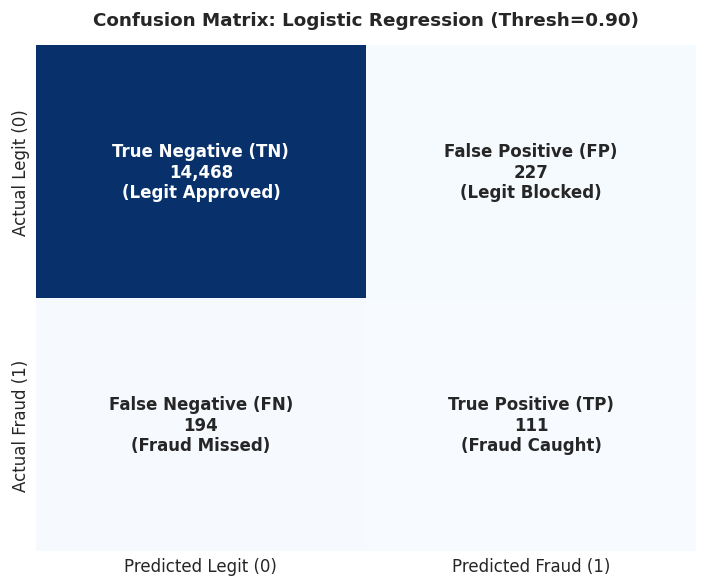

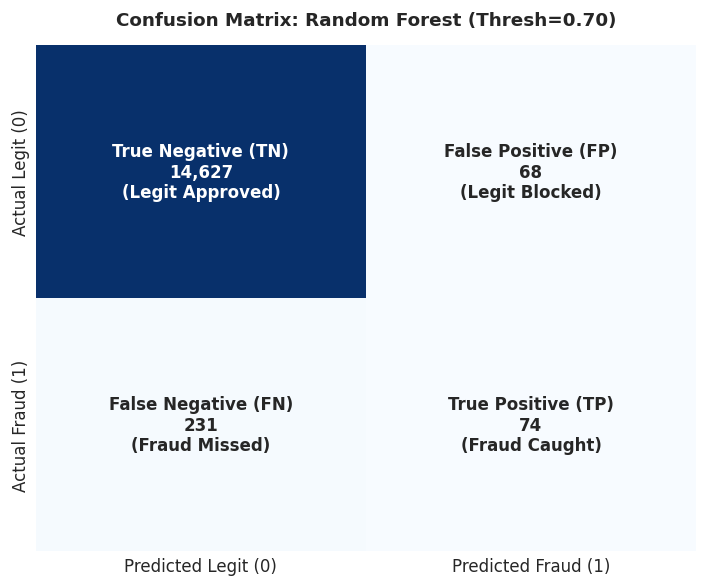

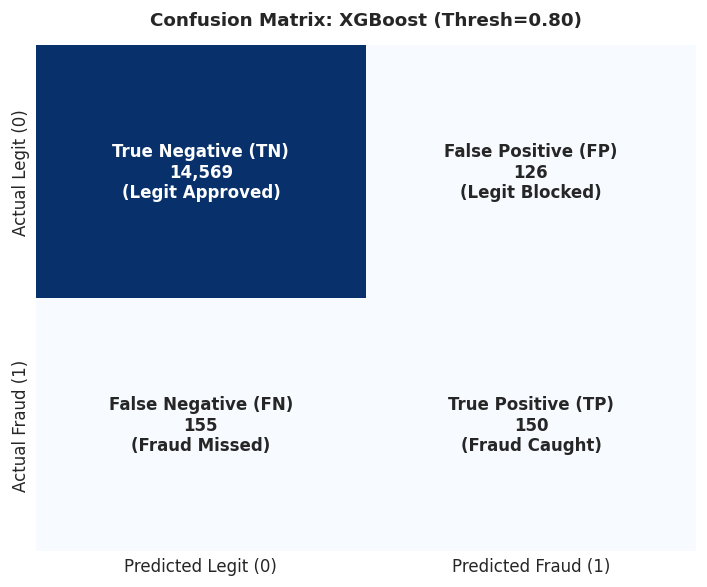

In [8]:
# Generate and save confusion matrices at selected optimal thresholds
lr_cm = plot_confusion_matrix(y_test, (lr_test_probs >= lr_opt_threshold).astype(int), f"Logistic Regression (Thresh={lr_opt_threshold:.2f})", FIG_DIR / "confusion_matrix_logistic.png")
plt.show()

rf_cm = plot_confusion_matrix(y_test, (rf_test_probs >= rf_opt_threshold).astype(int), f"Random Forest (Thresh={rf_opt_threshold:.2f})", FIG_DIR / "confusion_matrix_rf.png")
plt.show()

xgb_cm = plot_confusion_matrix(y_test, (xgb_test_probs >= xgb_opt_threshold).astype(int), f"XGBoost (Thresh={xgb_opt_threshold:.2f})", FIG_DIR / "confusion_matrix_xgb.png")
plt.show()


**12. Plot Precision-Recall & ROC Curves**

Comparative visualization of test set performance across probability thresholds:


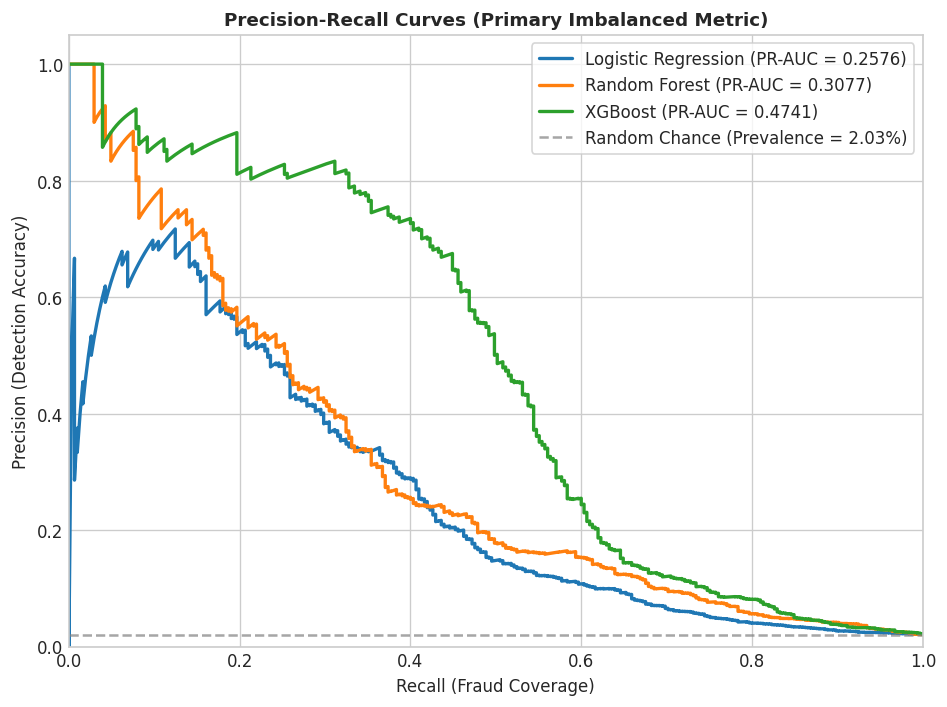

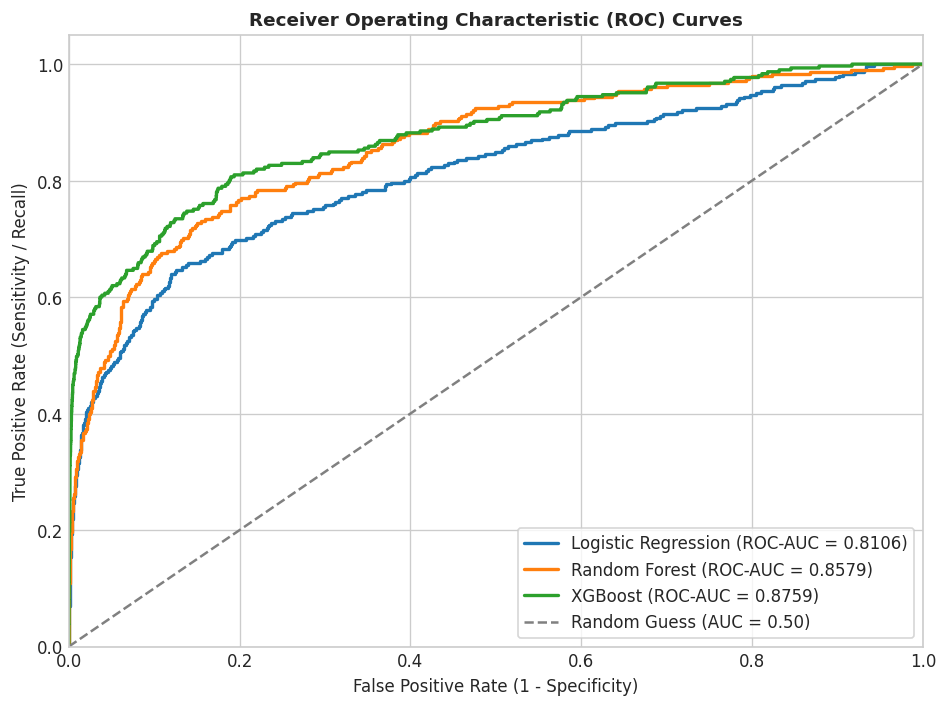

In [9]:
test_predictions = {
    "Logistic Regression": (y_test, lr_test_probs),
    "Random Forest": (y_test, rf_test_probs),
    "XGBoost": (y_test, xgb_test_probs)
}

pr_fig = plot_pr_curves(test_predictions, save_path=FIG_DIR / "pr_curve_baselines.png")
plt.show()

roc_fig = plot_roc_curves(test_predictions, save_path=FIG_DIR / "roc_curve_baselines.png")
plt.show()


**13. Save Machine-Readable Benchmark Artifacts**

We save two machine-readable CSV artifacts into `results/metrics/`:
1. `baseline_metrics.csv`: Final model comparison metrics.
2. `baseline_thresholds.csv`: Threshold curves across 0.05 to 0.95 on validation data.


In [10]:
# 1. Save final baseline metrics table
metrics_csv_path = METRICS_DIR / "baseline_metrics.csv"
comparison_df.to_csv(metrics_csv_path, index=False)
print(f"Saved baseline metrics to: {metrics_csv_path}")

# 2. Save full validation threshold sweep for all models
lr_thresh_df = evaluate_thresholds(y_val, lr_val_probs)
lr_thresh_df["Model"] = "Logistic Regression"

rf_thresh_df = evaluate_thresholds(y_val, rf_val_probs)
rf_thresh_df["Model"] = "Random Forest"

xgb_thresh_df = evaluate_thresholds(y_val, xgb_val_probs)
xgb_thresh_df["Model"] = "XGBoost"

all_thresh_df = pd.concat([lr_thresh_df, rf_thresh_df, xgb_thresh_df], ignore_index=True)
thresh_csv_path = METRICS_DIR / "baseline_thresholds.csv"
all_thresh_df.to_csv(thresh_csv_path, index=False)
print(f"Saved threshold sweep to: {thresh_csv_path}")


Saved baseline metrics to: C:\Ongoing Projects\2026.09.30 Multimodal-Financial-Fraud-Detector\Multimodal-Financial-Fraud-Detector\results\metrics\baseline_metrics.csv


Saved threshold sweep to: C:\Ongoing Projects\2026.09.30 Multimodal-Financial-Fraud-Detector\Multimodal-Financial-Fraud-Detector\results\metrics\baseline_thresholds.csv


**14. Empirical Conclusions & Transition to Phase 5**

We extract the final empirical conclusions directly from the measured test metrics without subjective predetermination:


In [11]:
best_model_row = comparison_df.loc[comparison_df["Test_PR_AUC"].idxmax()]
print("=== Empirical Baseline Benchmark Conclusions ===")
print(f"1. Top Performing Baseline: '{best_model_row['Model']}' with Test PR-AUC = {best_model_row['Test_PR_AUC']:.4f}")
print(f"2. Validation-Tuned Threshold for Top Model: {best_model_row['Selected_Threshold']:.2f}")
print(f"3. Final Test Performance at Selected Threshold:")
print(f"     - Precision: {best_model_row['Test_Precision']:.4f}")
print(f"     - Recall:    {best_model_row['Test_Recall']:.4f} ({int(best_model_row['Test_TP'])} / {int(best_model_row['Test_TP'] + best_model_row['Test_FN'])} frauds caught)")
print(f"     - False Positives: {int(best_model_row['Test_FP']):,}")

print("\nRoadmap to Phase 5 (PyTorch MLP):")
print(f"  The neural network in Phase 5 must aim to approach or surpass the baseline PR-AUC benchmark ({best_model_row['Test_PR_AUC']:.4f}).")
print("  In Phase 5, we start with numerical features and BCEWithLogitsLoss, then introduce categorical embeddings in Phase 6.")


=== Empirical Baseline Benchmark Conclusions ===
1. Top Performing Baseline: 'XGBoost' with Test PR-AUC = 0.4741
2. Validation-Tuned Threshold for Top Model: 0.80
3. Final Test Performance at Selected Threshold:
     - Precision: 0.5435
     - Recall:    0.4918 (150 / 305 frauds caught)
     - False Positives: 126

Roadmap to Phase 5 (PyTorch MLP):
  The neural network in Phase 5 must aim to approach or surpass the baseline PR-AUC benchmark (0.4741).
  In Phase 5, we start with numerical features and BCEWithLogitsLoss, then introduce categorical embeddings in Phase 6.
